# 04_perturbation_confidence_test_mel_nv

Incremental soft perturbation test for MEL vs NV CAMs.

Goal:
- Compute CAMs for the fine-tuned MEL vs NV CLS and GAP models.
- Incrementally perturb the hottest CAM regions: 0%, 5%, 10%, ..., 50% by default.
- Track target confidence, reference confidence, target drop, and Finer-CAM-style relative confidence drop.
- Create visual grids showing how the perturbed region grows.

Important interpretation:
- This does **not** prove clinical correctness.
- It tests whether changing highlighted regions affects the model prediction.
- RD follows the Finer-CAM idea: `RD = target_drop - reference_drop`.
- Positive RD means the perturbation hurts the target class more than the reference class.


## 0. Configuration


In [1]:
from pathlib import Path
import sys

# Notebook location: notebooks/mel_nv/04_perturbation_confidence_test_mel_nv.ipynb
# REPO_ROOT = Path("../..").resolve() # local notebook
REPO_ROOT = Path("..").resolve() # ubelix notebook
REPO_ROOT = REPO_ROOT / "master-thesis"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

CSV_PATH = REPO_ROOT / "data" / "HAM10000" / "mel_nv" / "ham_mel_nv_clean.csv"
IMG_DIR = REPO_ROOT / "data" / "HAM10000"

# Choose rows:
# - "qualitative": uses the 10 MEL + 10 NV CSV from notebook 00
# - "all_test": uses all test images from ham_mel_nv_clean.csv
SAMPLE_MODE = "all_test"  # "qualitative" or "all_test"
QUAL_CSV = REPO_ROOT / "data" / "HAM10000" / "mel_nv" / "ham_mel_nv_clean_qualitative_10_per_class_seed42.csv"

# Start with the same block used in the CAM notebook.
# You can change to -6 or -10 after notebook 02/03.
TARGET_BLOCK_INDEX = -1

# Use 0 or None for all rows in selected CSV.
# For smoke test, set NUM_SAMPLES = 2.
NUM_SAMPLES = 0
START_INDEX = 0

# MEL vs NV fixed class pair.
CLASS_NAMES = "MEL,NV"
LABEL_COL = "binary_label"
GT_COL = "gt_label"
IMAGE_COL = "image_rel_path"
ID_COL = "image_id"

# Finer-CAM settings
COMPARE_MODE = "gt_pair"
ALPHA = 0.8

# CAMs to compare
METHODS = ["gradcam_target", "gradcam_diff", "finercam"]
INCLUDE_RANDOM_BASELINE = True

# Incremental curve settings.
# 0..50 is usually enough for clean presentation.
# Full deletion-style curve: [i / 100 for i in range(0, 101, 5)]
# PERTURBATION_RATIOS = [i / 100 for i in range(0, 51, 5)] # 0..50% perturbation, in 5% steps
PERTURBATION_RATIOS = [i / 100 for i in range(0, 31, 5)] # 0..30% perturbation, in 5% steps

# Dermatology-relevant soft perturbations.
PERTURBATION_TYPES = [
    "darken",
    "desaturate",
    # "gaussian_noise",
]

DARKEN_FACTOR = 0.45
NOISE_STD = 0.05
RANDOM_SEED = 42
DEVICE = None  # None auto-selects cuda, mps, or cpu

# Visual examples
VIS_IMAGE_ID = None  # None uses first selected row. Or e.g. "ISIC_0024459"
VIS_METHOD = "finercam"
VIS_PERTURBATION = "desaturate"
# VIS_RATIOS = [0.0, 0.05, 0.10, 0.20, 0.30, 0.50]
VIS_RATIOS = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]

# Model scenarios
SCENARIOS = [
    {
        "name": "CLS HA 5.0",
        "short_name": "cls_ha5",
        "checkpoint": REPO_ROOT / "external" / "checkpoints5" / "checkpoint-best-cls-ha5.pth",
        "checkpoint_model_type": "panderm",
        "pooling": "cls",
    },
    {
        "name": "GAP HA 5.0",
        "short_name": "gap_ha5",
        "checkpoint": REPO_ROOT / "external" / "checkpoints5" / "checkpoint-best-gap-ha5.pth",
        "checkpoint_model_type": "panderm",
        "pooling": "mean",
    },
]

OUT_ROOT = REPO_ROOT / "outputs" / "mel_nv" / f"perturbation_confidence_{SAMPLE_MODE}_block{TARGET_BLOCK_INDEX}"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

SAVE_CAM_CACHE = True

print("REPO_ROOT:", REPO_ROOT)
print("CSV_PATH exists:", CSV_PATH.exists(), CSV_PATH)
print("QUAL_CSV exists:", QUAL_CSV.exists(), QUAL_CSV)
print("IMG_DIR exists:", IMG_DIR.exists(), IMG_DIR)
print("OUT_ROOT:", OUT_ROOT)
for s in SCENARIOS:
    print("\n", s["name"])
    print("  checkpoint exists:", Path(s["checkpoint"]).exists(), s["checkpoint"])
    print("  pooling:", s["pooling"])


REPO_ROOT: /storage/homefs/cn21m021/projects/master-thesis
CSV_PATH exists: True /storage/homefs/cn21m021/projects/master-thesis/data/HAM10000/mel_nv/ham_mel_nv_clean.csv
QUAL_CSV exists: True /storage/homefs/cn21m021/projects/master-thesis/data/HAM10000/mel_nv/ham_mel_nv_clean_qualitative_10_per_class_seed42.csv
IMG_DIR exists: True /storage/homefs/cn21m021/projects/master-thesis/data/HAM10000
OUT_ROOT: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/perturbation_confidence_all_test_block-1

 CLS HA 5.0
  checkpoint exists: True /storage/homefs/cn21m021/projects/master-thesis/external/checkpoints5/checkpoint-best-cls-ha5.pth
  pooling: cls

 GAP HA 5.0
  checkpoint exists: True /storage/homefs/cn21m021/projects/master-thesis/external/checkpoints5/checkpoint-best-gap-ha5.pth
  pooling: mean


## 1. Imports and helpers


In [2]:
import json
import warnings
from types import SimpleNamespace

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from scripts.generate_finer_cam_panderm import (
    PanDermCAMWrapper,
    build_class_maps,
    load_panderm_finetuned_model,
    vit_reshape_transform,
)
from src.cam.diff_cam import compute_cam_bundle

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)


In [3]:
def get_device(device_arg=None):
    if device_arg is not None:
        return device_arg
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


def build_eval_transform(image_size: int = 224):
    mean = (0.485, 0.456, 0.406)
    std = (0.229, 0.224, 0.225)
    return T.Compose([
        T.Resize(256),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])


IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


def unnormalize(x: torch.Tensor) -> torch.Tensor:
    mean = IMAGENET_MEAN.to(x.device)
    std = IMAGENET_STD.to(x.device)
    return torch.clamp(x * std + mean, 0.0, 1.0)


def normalize(x01: torch.Tensor) -> torch.Tensor:
    mean = IMAGENET_MEAN.to(x01.device)
    std = IMAGENET_STD.to(x01.device)
    return (torch.clamp(x01, 0.0, 1.0) - mean) / std


def load_rgb(path: Path) -> Image.Image:
    with Image.open(path) as img:
        return img.convert("RGB")


def resolve_image_path(row, img_dir: Path, image_col: str = IMAGE_COL) -> Path:
    image_name = str(row[image_col])
    p = Path(image_name)
    if p.is_absolute():
        return p
    candidate = img_dir / p
    if candidate.exists():
        return candidate
    if image_name.endswith((".jpg", ".jpeg", ".png")):
        return img_dir / image_name
    return img_dir / f"{image_name}.jpg"


def get_cam_target_layer(model_raw: torch.nn.Module, target_block_index: int = -1):
    blocks = model_raw.backbone.blocks if hasattr(model_raw, "backbone") else model_raw.blocks
    n_blocks = len(blocks)
    resolved_index = n_blocks + target_block_index if target_block_index < 0 else target_block_index
    if resolved_index < 0 or resolved_index >= n_blocks:
        raise ValueError(
            f"target_block_index={target_block_index} resolves to {resolved_index}, "
            f"but model has {n_blocks} blocks."
        )
    return blocks[resolved_index].norm1


def minmax_cam(cam_np: np.ndarray) -> np.ndarray:
    cam = np.asarray(cam_np).squeeze().astype(np.float32)
    cam = cam - np.nanmin(cam)
    denom = np.nanmax(cam) + 1e-8
    return cam / denom


def cam_to_tensor(cam_np: np.ndarray, device: str) -> torch.Tensor:
    return torch.from_numpy(minmax_cam(cam_np)).float().unsqueeze(0).to(device)


def resize_cam_to_image(cam: torch.Tensor, image_hw: tuple[int, int]) -> torch.Tensor:
    if cam.ndim == 2:
        cam = cam.unsqueeze(0)
    if cam.shape[-2:] != image_hw:
        cam = nn.functional.interpolate(
            cam.unsqueeze(1),
            size=image_hw,
            mode="bilinear",
            align_corners=False,
        ).squeeze(1)
    return cam


def mask_from_cam(cam: torch.Tensor, ratio: float) -> torch.Tensor:
    if ratio <= 0:
        return torch.zeros_like(cam, dtype=torch.bool)
    ratio = min(max(float(ratio), 0.0), 1.0)
    flat = cam.flatten()
    threshold = torch.quantile(flat, 1.0 - ratio)
    return cam >= threshold


def random_mask_from_fixed_order(cam: torch.Tensor, ratio: float, perm: torch.Tensor) -> torch.Tensor:
    if ratio <= 0:
        return torch.zeros_like(cam, dtype=torch.bool)
    n = cam.numel()
    k = max(1, int(round(float(ratio) * n)))
    flat = torch.zeros(n, dtype=torch.bool, device=cam.device)
    flat[perm[:k]] = True
    return flat.view_as(cam)


def perturb_image_soft(
    image_norm: torch.Tensor,
    mask_hw: torch.Tensor,
    perturbation_type: str,
    darken_factor: float = 0.45,
    noise_std: float = 0.05,
    generator: torch.Generator | None = None,
) -> torch.Tensor:
    x = unnormalize(image_norm).clone()
    mask = mask_hw.bool().to(x.device)
    mask3 = mask.unsqueeze(0).unsqueeze(0).expand_as(x)

    if perturbation_type == "darken":
        x[mask3] = x[mask3] * float(darken_factor)

    elif perturbation_type == "desaturate":
        r = x[:, 0:1]
        g = x[:, 1:2]
        b = x[:, 2:3]
        gray = 0.299 * r + 0.587 * g + 0.114 * b
        gray3 = gray.expand_as(x)
        x = torch.where(mask3, gray3, x)

    elif perturbation_type == "gaussian_noise":
        noise = torch.randn(x.shape, device=x.device, generator=generator) * float(noise_std)
        x_noisy = torch.clamp(x + noise, 0.0, 1.0)
        x = torch.where(mask3, x_noisy, x)

    else:
        raise ValueError(f"Unknown perturbation_type: {perturbation_type}")

    return normalize(x)


def tensor_to_rgb_np(x_norm: torch.Tensor) -> np.ndarray:
    x01 = unnormalize(x_norm.detach()).squeeze(0).permute(1, 2, 0).cpu().numpy()
    return np.clip(x01, 0.0, 1.0)


def overlay_mask_on_rgb(rgb01: np.ndarray, mask: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    mask = mask.astype(bool)
    out = rgb01.copy()
    overlay = np.zeros_like(out)
    overlay[..., 0] = 1.0
    out[mask] = (1.0 - alpha) * out[mask] + alpha * overlay[mask]
    return np.clip(out, 0.0, 1.0)


def overlay_cam_on_rgb(rgb01: np.ndarray, cam01: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    cam01 = minmax_cam(cam01)
    heat = cv2.applyColorMap(np.uint8(255 * cam01), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    if heat.shape[:2] != rgb01.shape[:2]:
        heat = cv2.resize(heat, (rgb01.shape[1], rgb01.shape[0]), interpolation=cv2.INTER_LINEAR)
    return np.clip((1.0 - alpha) * rgb01 + alpha * heat, 0.0, 1.0)


## 2. Load selected rows


In [4]:
if SAMPLE_MODE == "qualitative":
    df = pd.read_csv(QUAL_CSV, low_memory=False)
elif SAMPLE_MODE == "all_test":
    df = pd.read_csv(CSV_PATH, low_memory=False)
    df = df[df["split"].astype(str).str.lower().eq("test")].copy()
    df = df.sort_values([GT_COL, ID_COL]).reset_index(drop=True)
else:
    raise ValueError("SAMPLE_MODE must be qualitative or all_test")

required_cols = [ID_COL, IMAGE_COL, GT_COL, LABEL_COL]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in selected CSV: {missing}")

if START_INDEX > 0:
    df = df.iloc[START_INDEX:].copy()

if NUM_SAMPLES is not None and int(NUM_SAMPLES) > 0:
    df = df.head(int(NUM_SAMPLES)).copy()

df = df.reset_index(drop=True)

print("Rows to evaluate:", len(df))
display(df[[ID_COL, GT_COL, LABEL_COL, IMAGE_COL]].head())
display(df[GT_COL].value_counts())


Rows to evaluate: 1021


,image_id,gt_label,binary_label,image_rel_path
0,ISIC_0024459,MEL,0,images/ISIC_0024459.jpg
1,ISIC_0024571,MEL,0,images/ISIC_0024571.jpg
2,ISIC_0024624,MEL,0,images/ISIC_0024624.jpg
3,ISIC_0024640,MEL,0,images/ISIC_0024640.jpg
4,ISIC_0024756,MEL,0,images/ISIC_0024756.jpg


gt_label
NV     951
MEL     70
Name: count, dtype: int64

## 3. Load model and compute CAMs


In [5]:
device = get_device(DEVICE)
print("Device:", device)

class_names = [x.strip() for x in CLASS_NAMES.split(",")]
class_to_idx, idx_to_class = build_class_maps(class_names)
print("Class names:", class_names)

def load_scenario_model(scenario):
    model_raw, model_info = load_panderm_finetuned_model(
        checkpoint_path=str(scenario["checkpoint"]),
        num_classes=len(class_names),
        class_to_idx=class_to_idx,
        idx_to_class=idx_to_class,
        device=device,
        checkpoint_model_type=scenario["checkpoint_model_type"],
        use_seg_gate=False,
        pooling=scenario["pooling"],
    )
    model = PanDermCAMWrapper(model_raw)
    model.eval()
    target_layer = get_cam_target_layer(model_raw, target_block_index=TARGET_BLOCK_INDEX)
    print("\nLoaded", scenario["name"])
    print("Model info:", model_info)
    print("Target block index:", TARGET_BLOCK_INDEX)
    return model_raw, model, target_layer, model_info


transform = build_eval_transform()


Device: cuda
Class names: ['MEL', 'NV']


In [6]:
def determine_pair_indices(gt_idx: int):
    assert gt_idx in (0, 1), f"Unexpected gt_idx={gt_idx}, expected 0 (MEL) or 1 (NV)"
    A_idx = int(gt_idx)
    B_idx = 1 - A_idx
    return A_idx, B_idx, [B_idx]


def cache_path_for(cache_dir: Path, image_id: str, method: str) -> Path:
    return cache_dir / image_id / f"{method}.npy"


def load_cached_cams(cache_dir: Path, image_id: str, methods: list[str]):
    cams = {}
    for method in methods:
        p = cache_path_for(cache_dir, image_id, method)
        if not p.exists():
            return None
        cams[method] = np.load(p)
    return cams


def save_cached_cams(cache_dir: Path, image_id: str, cams: dict[str, np.ndarray]):
    out_dir = cache_dir / image_id
    out_dir.mkdir(parents=True, exist_ok=True)
    for method, cam in cams.items():
        np.save(out_dir / f"{method}.npy", np.asarray(cam).astype(np.float32))


def compute_or_load_cams(cache_dir: Path, model, target_layer, image_id: str, image_tensor: torch.Tensor, rgb_float: np.ndarray, gt_idx: int):
    requested_nonrandom = [m for m in METHODS if m != "random_region"]

    if SAVE_CAM_CACHE:
        cached = load_cached_cams(cache_dir, image_id, requested_nonrandom)
        if cached is not None:
            return cached

    A_idx, B_idx, comparison_categories = determine_pair_indices(gt_idx)

    bundle = compute_cam_bundle(
        model=model,
        input_tensor=image_tensor,
        rgb_float=rgb_float,
        target_layer=target_layer,
        reshape_transform=vit_reshape_transform,
        method="finercam",
        A=A_idx,
        B=B_idx,
        comparison_categories=comparison_categories,
        alpha=ALPHA,
        include_extra_maps=False,
    )

    gradcam_diff_cam = bundle.get("cam_diff") if bundle.get("cam_diff") is not None else bundle.get("cam_gradcam_diff")
    cams = {
        "gradcam_target": bundle.get("cam_gradcam"),
        "gradcam_diff": gradcam_diff_cam,
        "finercam": bundle.get("cam_finercam"),
    }
    cams = {k: minmax_cam(v) for k, v in cams.items() if v is not None and k in requested_nonrandom}

    if SAVE_CAM_CACHE:
        save_cached_cams(cache_dir, image_id, cams)

    return cams


## 4. Incremental perturbation evaluation


In [7]:
def evaluate_one_image_incremental(row, scenario, model, target_layer, cache_dir: Path, rng: torch.Generator):
    image_id = str(row[ID_COL])
    gt_idx = int(row[LABEL_COL])
    gt_name = str(row[GT_COL])

    image_path = resolve_image_path(row, IMG_DIR, image_col=IMAGE_COL)
    rgb = load_rgb(image_path)
    image_tensor = transform(rgb).unsqueeze(0).to(device)

    rgb_float = np.array(rgb).astype(np.float32) / 255.0
    rgb_float = cv2.resize(rgb_float, (224, 224), interpolation=cv2.INTER_LINEAR)

    with torch.no_grad():
        original_logits = model(image_tensor)
        original_probs = torch.softmax(original_logits, dim=1)[0].detach().cpu().numpy()

    pred_idx = int(np.argmax(original_probs))
    pred_name = class_names[pred_idx]
    pred_prob = float(original_probs[pred_idx])

    target_idx, reference_idx, comparison_categories = determine_pair_indices(gt_idx)
    target_name = class_names[target_idx]
    reference_name = class_names[reference_idx]

    original_target_conf = float(original_probs[target_idx])
    original_reference_conf = float(original_probs[reference_idx])

    cams = compute_or_load_cams(
        cache_dir=cache_dir,
        model=model,
        target_layer=target_layer,
        image_id=image_id,
        image_tensor=image_tensor,
        rgb_float=rgb_float,
        gt_idx=gt_idx,
    )

    if INCLUDE_RANDOM_BASELINE:
        cams["random_region"] = np.zeros((224, 224), dtype=np.float32)

    rows = []

    for method, cam_np in cams.items():
        if method == "random_region":
            cam_t = torch.zeros((1, 224, 224), dtype=torch.float32, device=device)
        else:
            cam_t = cam_to_tensor(cam_np, device=device)
            cam_t = resize_cam_to_image(cam_t, image_tensor.shape[-2:])

        cam_hw = cam_t[0]

        if method == "random_region":
            random_perm = torch.randperm(cam_hw.numel(), device=cam_hw.device, generator=rng)
        else:
            random_perm = None

        for perturbation_type in PERTURBATION_TYPES:
            for ratio in PERTURBATION_RATIOS:
                if method == "random_region":
                    base_mask = random_mask_from_fixed_order(cam_hw, ratio=ratio, perm=random_perm)
                else:
                    base_mask = mask_from_cam(cam_hw, ratio=ratio)

                perturbed = perturb_image_soft(
                    image_norm=image_tensor,
                    mask_hw=base_mask,
                    perturbation_type=perturbation_type,
                    darken_factor=DARKEN_FACTOR,
                    noise_std=NOISE_STD,
                    generator=rng,
                )

                with torch.no_grad():
                    pert_logits = model(perturbed)
                    pert_probs = torch.softmax(pert_logits, dim=1)[0].detach().cpu().numpy()

                pert_target_conf = float(pert_probs[target_idx])
                pert_reference_conf = float(pert_probs[reference_idx])
                target_drop = original_target_conf - pert_target_conf
                reference_drop = original_reference_conf - pert_reference_conf
                finer_cam_rd = target_drop - reference_drop

                pert_pred_idx = int(np.argmax(pert_probs))
                pert_pred_name = class_names[pert_pred_idx]
                pert_pred_prob = float(pert_probs[pert_pred_idx])

                rows.append({
                    "model_name": scenario["name"],
                    "model_short_name": scenario["short_name"],
                    "pooling": scenario["pooling"],
                    "checkpoint": str(scenario["checkpoint"]),
                    "image_id": image_id,
                    "image_path": str(image_path),
                    "gt_idx": gt_idx,
                    "gt_name": gt_name,
                    "pred_idx": pred_idx,
                    "pred_name": pred_name,
                    "pred_prob": pred_prob,
                    "prediction_correct": bool(pred_idx == gt_idx),
                    "target_idx": target_idx,
                    "target_name": target_name,
                    "reference_idx": reference_idx,
                    "reference_name": reference_name,
                    "original_target_confidence": original_target_conf,
                    "original_reference_confidence": original_reference_conf,
                    "method": method,
                    "perturbation_type": perturbation_type,
                    "ratio": float(ratio),
                    "perturbed_target_confidence": pert_target_conf,
                    "perturbed_reference_confidence": pert_reference_conf,
                    "target_drop": float(target_drop),
                    "reference_drop": float(reference_drop),
                    "finer_cam_rd": float(finer_cam_rd),
                    "relative_target_drop": float(target_drop / max(original_target_conf, 1e-8)),
                    "perturbed_pred_idx": pert_pred_idx,
                    "perturbed_pred_name": pert_pred_name,
                    "perturbed_pred_prob": pert_pred_prob,
                    "pred_changed": bool(pert_pred_idx != pred_idx),
                    "target_block_index": TARGET_BLOCK_INDEX,
                    "compare_mode": COMPARE_MODE,
                })

    return rows


In [8]:
all_rows = []

for scenario in SCENARIOS:
    scenario_out = OUT_ROOT / scenario["short_name"]
    scenario_out.mkdir(parents=True, exist_ok=True)
    cache_dir = scenario_out / "cam_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)

    model_raw, model, target_layer, model_info = load_scenario_model(scenario)

    rng = torch.Generator(device=device)
    rng.manual_seed(RANDOM_SEED)

    scenario_rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"perturbation {scenario['short_name']}"):
        try:
            rows = evaluate_one_image_incremental(row, scenario, model, target_layer, cache_dir, rng)
            scenario_rows.extend(rows)
            all_rows.extend(rows)
        except Exception as e:
            image_id = str(row.get(ID_COL, "unknown"))
            print(f"[warn] failed {scenario['short_name']} image_id={image_id}: {e}")
            fail_row = {
                "model_name": scenario["name"],
                "model_short_name": scenario["short_name"],
                "image_id": image_id,
                "status": "failed",
                "error": str(e),
            }
            scenario_rows.append(fail_row)
            all_rows.append(fail_row)

    scenario_df = pd.DataFrame(scenario_rows)
    scenario_path = scenario_out / "incremental_soft_perturbation_per_sample.csv"
    scenario_df.to_csv(scenario_path, index=False)
    print("Saved:", scenario_path)

    del model_raw, model, target_layer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

per_sample_df = pd.DataFrame(all_rows)
per_sample_path = OUT_ROOT / "incremental_soft_perturbation_per_sample_combined.csv"
per_sample_df.to_csv(per_sample_path, index=False)

print("Saved combined:", per_sample_path)
print("Shape:", per_sample_df.shape)
display(per_sample_df.head())


[warn] load_state_dict mismatch: missing=2, unexpected=2
  missing sample: ['norm.weight', 'norm.bias']
  unexpected sample: ['fc_norm.weight', 'fc_norm.bias']

Loaded CLS HA 5.0
Model info: {'arch': 'PanDerm Base FT', 'variant': 'base', 'num_classes': 2, 'pooling': 'cls', 'use_mean_pooling': False, 'checkpoint_name': 'checkpoint-best-cls-ha5.pth', 'checkpoint_format': 'official_pth', 'checkpoint_model_type': 'panderm', 'use_seg_gate': False, 'seg_gate_bg_keep': 0.15, 'seg_gate_detach': True, 'class_to_idx': {'MEL': 0, 'NV': 1}, 'idx_to_class': {0: 'MEL', 1: 'NV'}, 'image_size': 224, 'stage_name': None, 'epoch': 'best'}
Target block index: -1


perturbation cls_ha5:   0%|          | 0/1021 [00:00<?, ?it/s]

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/perturbation_confidence_all_test_block-1/cls_ha5/incremental_soft_perturbation_per_sample.csv

Loaded GAP HA 5.0
Model info: {'arch': 'PanDerm Base FT', 'variant': 'base', 'num_classes': 2, 'pooling': 'mean', 'use_mean_pooling': True, 'checkpoint_name': 'checkpoint-best-gap-ha5.pth', 'checkpoint_format': 'official_pth', 'checkpoint_model_type': 'panderm', 'use_seg_gate': False, 'seg_gate_bg_keep': 0.15, 'seg_gate_detach': True, 'class_to_idx': {'MEL': 0, 'NV': 1}, 'idx_to_class': {0: 'MEL', 1: 'NV'}, 'image_size': 224, 'stage_name': None, 'epoch': 'best'}
Target block index: -1


perturbation gap_ha5:   0%|          | 0/1021 [00:00<?, ?it/s]

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/perturbation_confidence_all_test_block-1/gap_ha5/incremental_soft_perturbation_per_sample.csv
Saved combined: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/perturbation_confidence_all_test_block-1/incremental_soft_perturbation_per_sample_combined.csv
Shape: (114352, 33)


,model_name,model_short_name,pooling,checkpoint,image_id,image_path,gt_idx,gt_name,pred_idx,pred_name,pred_prob,prediction_correct,target_idx,target_name,reference_idx,reference_name,original_target_confidence,original_reference_confidence,method,perturbation_type,ratio,perturbed_target_confidence,perturbed_reference_confidence,target_drop,reference_drop,finer_cam_rd,relative_target_drop,perturbed_pred_idx,perturbed_pred_name,perturbed_pred_prob,pred_changed,target_block_index,compare_mode
0,CLS HA 5.0,cls_ha5,cls,/storage/homefs/cn21m021/projects/master-thesi...,ISIC_0024459,/storage/homefs/cn21m021/projects/master-thesi...,0,MEL,0,MEL,0.990709,True,0,MEL,1,NV,0.990709,0.009291,gradcam_target,darken,0.00,0.990709,0.009291,0.000000,4.656613e-09,-4.656613e-09,0.000000,0,MEL,0.990709,False,-1,gt_pair
1,CLS HA 5.0,cls_ha5,cls,/storage/homefs/cn21m021/projects/master-thesi...,ISIC_0024459,/storage/homefs/cn21m021/projects/master-thesi...,0,MEL,0,MEL,0.990709,True,0,MEL,1,NV,0.990709,0.009291,gradcam_target,darken,0.05,0.971520,0.028480,0.019189,-1.918930e-02,3.837860e-02,0.019369,0,MEL,0.971520,False,-1,gt_pair
2,CLS HA 5.0,cls_ha5,cls,/storage/homefs/cn21m021/projects/master-thesi...,ISIC_0024459,/storage/homefs/cn21m021/projects/master-thesi...,0,MEL,0,MEL,0.990709,True,0,MEL,1,NV,0.990709,0.009291,gradcam_target,darken,0.10,0.966161,0.033839,0.024548,-2.454787e-02,4.909568e-02,0.024778,0,MEL,0.966161,False,-1,gt_pair
3,CLS HA 5.0,cls_ha5,cls,/storage/homefs/cn21m021/projects/master-thesi...,ISIC_0024459,/storage/homefs/cn21m021/projects/master-thesi...,0,MEL,0,MEL,0.990709,True,0,MEL,1,NV,0.990709,0.009291,gradcam_target,darken,0.15,0.968582,0.031418,0.022127,-2.212729e-02,4.425456e-02,0.022335,0,MEL,0.968582,False,-1,gt_pair
4,CLS HA 5.0,cls_ha5,cls,/storage/homefs/cn21m021/projects/master-thesi...,ISIC_0024459,/storage/homefs/cn21m021/projects/master-thesi...,0,MEL,0,MEL,0.990709,True,0,MEL,1,NV,0.990709,0.009291,gradcam_target,darken,0.20,0.958423,0.041577,0.032286,-3.228643e-02,6.457278e-02,0.032589,0,MEL,0.958423,False,-1,gt_pair


## 5. Summaries and AUC tables


In [9]:
if "status" in per_sample_df.columns:
    ok_df = per_sample_df[per_sample_df["status"].fillna("ok") != "failed"].copy()
else:
    ok_df = per_sample_df.copy()

curve_summary = (
    ok_df
    .groupby(["model_short_name", "model_name", "pooling", "method", "perturbation_type", "ratio"], dropna=False)
    .agg(
        n=("image_id", "count"),
        target_confidence_mean=("perturbed_target_confidence", "mean"),
        target_confidence_std=("perturbed_target_confidence", "std"),
        reference_confidence_mean=("perturbed_reference_confidence", "mean"),
        reference_confidence_std=("perturbed_reference_confidence", "std"),
        target_drop_mean=("target_drop", "mean"),
        target_drop_std=("target_drop", "std"),
        reference_drop_mean=("reference_drop", "mean"),
        reference_drop_std=("reference_drop", "std"),
        finer_cam_rd_mean=("finer_cam_rd", "mean"),
        finer_cam_rd_std=("finer_cam_rd", "std"),
        relative_target_drop_mean=("relative_target_drop", "mean"),
        pred_changed_rate=("pred_changed", "mean"),
        original_target_confidence_mean=("original_target_confidence", "mean"),
        original_reference_confidence_mean=("original_reference_confidence", "mean"),
    )
    .reset_index()
)

curve_summary_path = OUT_ROOT / "incremental_soft_perturbation_curves_summary.csv"
curve_summary.to_csv(curve_summary_path, index=False)

print("Saved:", curve_summary_path)
display(curve_summary.head(20))


Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/perturbation_confidence_all_test_block-1/incremental_soft_perturbation_curves_summary.csv


,model_short_name,model_name,pooling,method,perturbation_type,ratio,n,target_confidence_mean,target_confidence_std,reference_confidence_mean,reference_confidence_std,target_drop_mean,target_drop_std,reference_drop_mean,reference_drop_std,finer_cam_rd_mean,finer_cam_rd_std,relative_target_drop_mean,pred_changed_rate,original_target_confidence_mean,original_reference_confidence_mean
0,cls_ha5,CLS HA 5.0,cls,finercam,darken,0.00,1021,0.820237,0.299830,0.179763,0.299830,-3.643651e-09,1.171450e-07,4.002646e-09,1.141213e-07,-7.646297e-09,2.291382e-07,-1.090696e-08,0.000000,0.820237,0.179763
1,cls_ha5,CLS HA 5.0,cls,finercam,darken,0.05,1021,0.843705,0.273609,0.156295,0.273609,-2.346880e-02,7.398738e-02,2.346880e-02,7.398738e-02,-4.693760e-02,1.479748e-01,-1.607637e-01,0.041136,0.820237,0.179763
2,cls_ha5,CLS HA 5.0,cls,finercam,darken,0.10,1021,0.859658,0.249794,0.140342,0.249794,-3.942105e-02,1.051715e-01,3.942105e-02,1.051715e-01,-7.884211e-02,2.103430e-01,-3.345017e-01,0.060725,0.820237,0.179763
3,cls_ha5,CLS HA 5.0,cls,finercam,darken,0.15,1021,0.867242,0.234036,0.132758,0.234036,-4.700537e-02,1.274380e-01,4.700537e-02,1.274380e-01,-9.401074e-02,2.548761e-01,-4.575915e-01,0.078355,0.820237,0.179763
4,cls_ha5,CLS HA 5.0,cls,finercam,darken,0.20,1021,0.871519,0.221900,0.128481,0.221900,-5.128189e-02,1.448732e-01,5.128189e-02,1.448732e-01,-1.025638e-01,2.897463e-01,-5.717796e-01,0.086190,0.820237,0.179763
5,cls_ha5,CLS HA 5.0,cls,finercam,darken,0.25,1021,0.874661,0.210618,0.125339,0.210618,-5.442389e-02,1.563967e-01,5.442389e-02,1.563967e-01,-1.088478e-01,3.127934e-01,-6.970523e-01,0.095005,0.820237,0.179763
6,cls_ha5,CLS HA 5.0,cls,finercam,darken,0.30,1021,0.876945,0.200654,0.123055,0.200654,-5.670798e-02,1.677917e-01,5.670798e-02,1.677917e-01,-1.134160e-01,3.355835e-01,-8.102591e-01,0.098923,0.820237,0.179763
7,cls_ha5,CLS HA 5.0,cls,finercam,desaturate,0.00,1021,0.820237,0.299830,0.179763,0.299830,-3.643651e-09,1.171450e-07,4.002646e-09,1.141213e-07,-7.646297e-09,2.291382e-07,-1.090696e-08,0.000000,0.820237,0.179763
8,cls_ha5,CLS HA 5.0,cls,finercam,desaturate,0.05,1021,0.849003,0.275550,0.150997,0.275550,-2.876686e-02,6.984319e-02,2.876686e-02,6.984319e-02,-5.753371e-02,1.396864e-01,-1.524328e-01,0.039177,0.820237,0.179763
9,cls_ha5,CLS HA 5.0,cls,finercam,desaturate,0.10,1021,0.856570,0.258755,0.143430,0.258755,-3.633292e-02,9.077900e-02,3.633292e-02,9.077901e-02,-7.266584e-02,1.815580e-01,-2.812740e-01,0.050930,0.820237,0.179763


In [10]:
def trapezoid_auc(x, y):
    return float(np.trapezoid(y, x=x))


auc_rows = []
for (model_short_name, model_name, pooling, method, perturbation_type), sub in curve_summary.groupby(
    ["model_short_name", "model_name", "pooling", "method", "perturbation_type"]
):
    sub = sub.sort_values("ratio")
    x = sub["ratio"].values.astype(float)

    auc_rows.append({
        "model_short_name": model_short_name,
        "model_name": model_name,
        "pooling": pooling,
        "method": method,
        "perturbation_type": perturbation_type,
        "target_confidence_auc": trapezoid_auc(x, sub["target_confidence_mean"].values),
        "target_drop_auc": trapezoid_auc(x, sub["target_drop_mean"].values),
        "rd_auc": trapezoid_auc(x, sub["finer_cam_rd_mean"].values),
        "mean_target_drop_at_30": float(sub.loc[np.isclose(sub["ratio"], 0.30), "target_drop_mean"].mean()),
        "mean_rd_at_30": float(sub.loc[np.isclose(sub["ratio"], 0.30), "finer_cam_rd_mean"].mean()),
        "pred_changed_rate_at_30": float(sub.loc[np.isclose(sub["ratio"], 0.30), "pred_changed_rate"].mean()),
    })

auc_df = pd.DataFrame(auc_rows)
auc_out = OUT_ROOT / "incremental_soft_perturbation_auc_summary.csv"
auc_df.to_csv(auc_out, index=False)

print("Saved:", auc_out)
display(auc_df.sort_values(["model_short_name", "perturbation_type", "rd_auc"], ascending=[True, True, False]))


Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/perturbation_confidence_all_test_block-1/incremental_soft_perturbation_auc_summary.csv


,model_short_name,model_name,pooling,method,perturbation_type,target_confidence_auc,target_drop_auc,rd_auc,mean_target_drop_at_30,mean_rd_at_30,pred_changed_rate_at_30
6,cls_ha5,CLS HA 5.0,cls,random_region,darken,0.244500,0.001571,0.003143,-0.022586,-0.045172,0.186092
0,cls_ha5,CLS HA 5.0,cls,finercam,darken,0.258269,-0.012198,-0.024396,-0.056708,-0.113416,0.098923
4,cls_ha5,CLS HA 5.0,cls,gradcam_target,darken,0.258320,-0.012249,-0.024497,-0.059664,-0.119327,0.091087
2,cls_ha5,CLS HA 5.0,cls,gradcam_diff,darken,0.265885,-0.019814,-0.039628,-0.088653,-0.177306,0.130264
5,cls_ha5,CLS HA 5.0,cls,gradcam_target,desaturate,0.253305,-0.007234,-0.014469,-0.045013,-0.090027,0.082272
7,cls_ha5,CLS HA 5.0,cls,random_region,desaturate,0.255549,-0.009478,-0.018956,-0.046082,-0.092165,0.090108
1,cls_ha5,CLS HA 5.0,cls,finercam,desaturate,0.256556,-0.010485,-0.020970,-0.040560,-0.081120,0.082272
3,cls_ha5,CLS HA 5.0,cls,gradcam_diff,desaturate,0.259404,-0.013333,-0.026667,-0.055525,-0.111050,0.100881
14,gap_ha5,GAP HA 5.0,mean,random_region,darken,0.221242,0.010793,0.021586,0.008853,0.017706,0.166503
10,gap_ha5,GAP HA 5.0,mean,gradcam_diff,darken,0.238447,-0.006412,-0.012824,0.000688,0.001376,0.073457


## 6. Curve plots


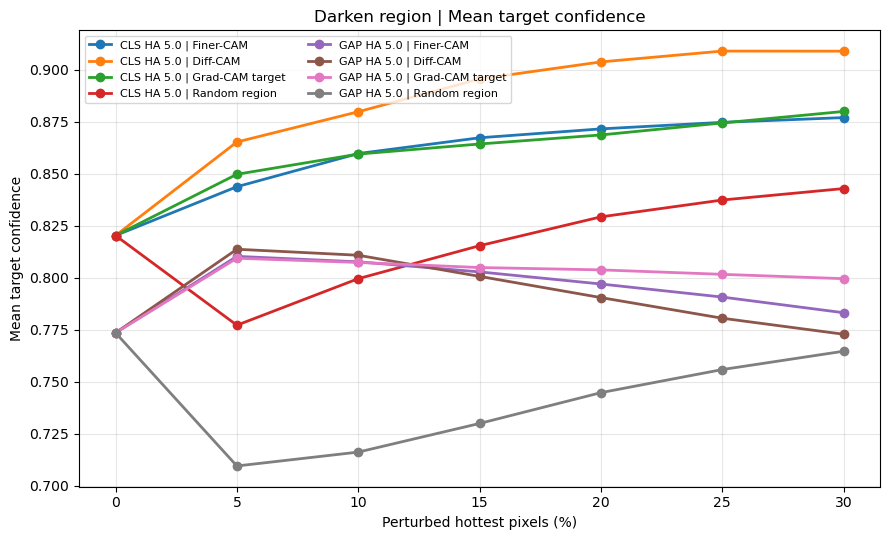

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/perturbation_confidence_all_test_block-1/curve_target_confidence_darken.png


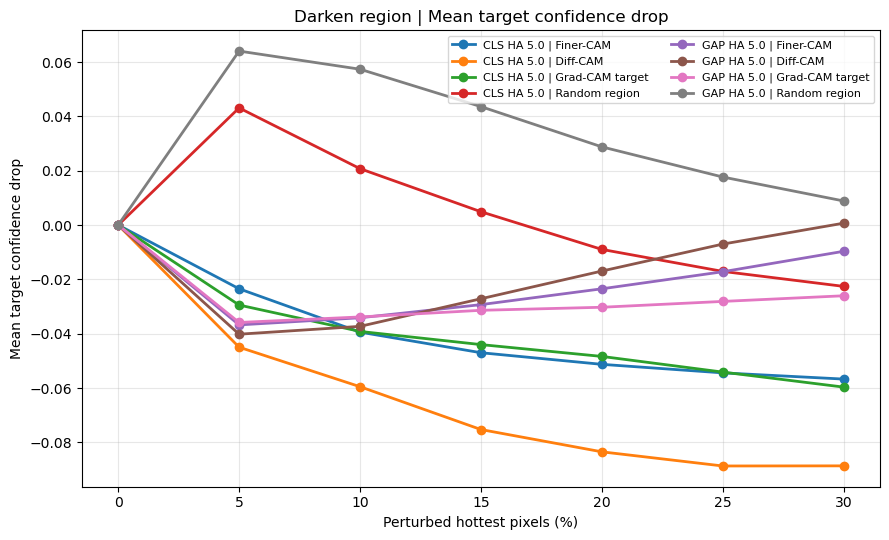

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/perturbation_confidence_all_test_block-1/curve_target_drop_darken.png


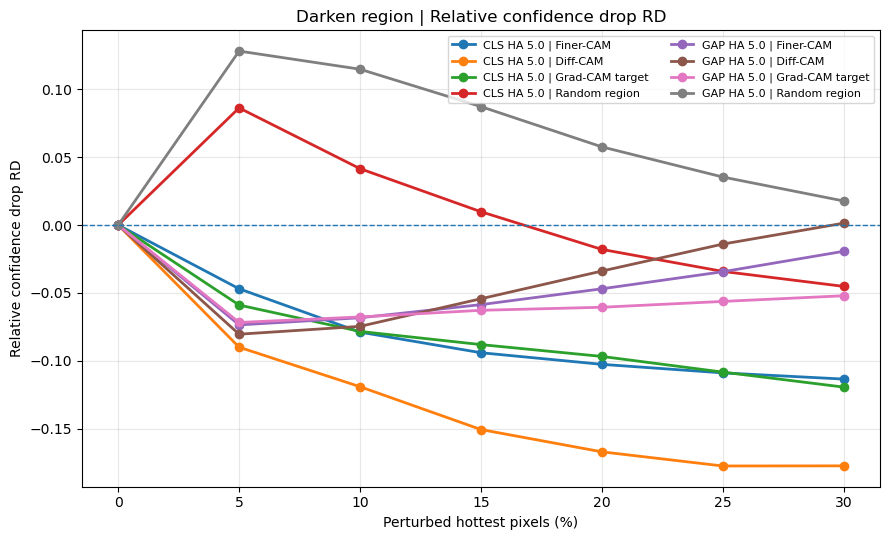

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/perturbation_confidence_all_test_block-1/curve_rd_darken.png


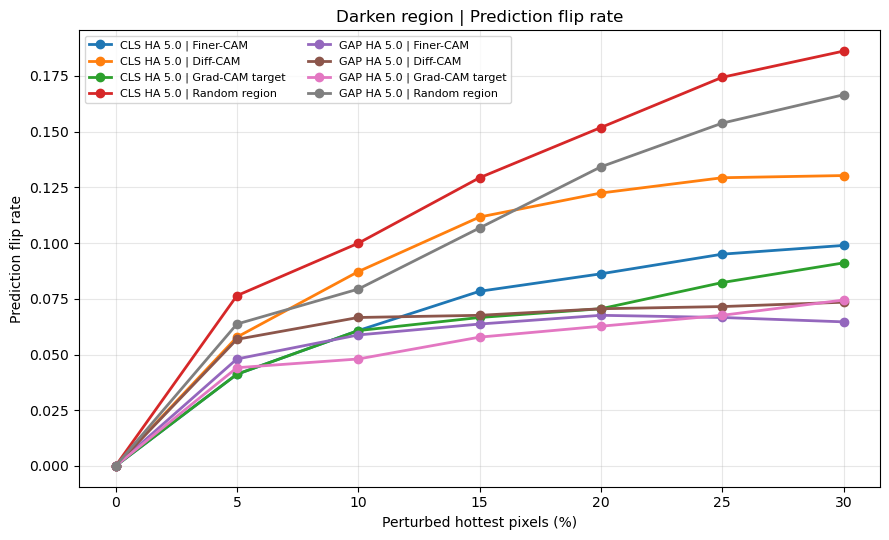

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/perturbation_confidence_all_test_block-1/curve_flip_rate_darken.png


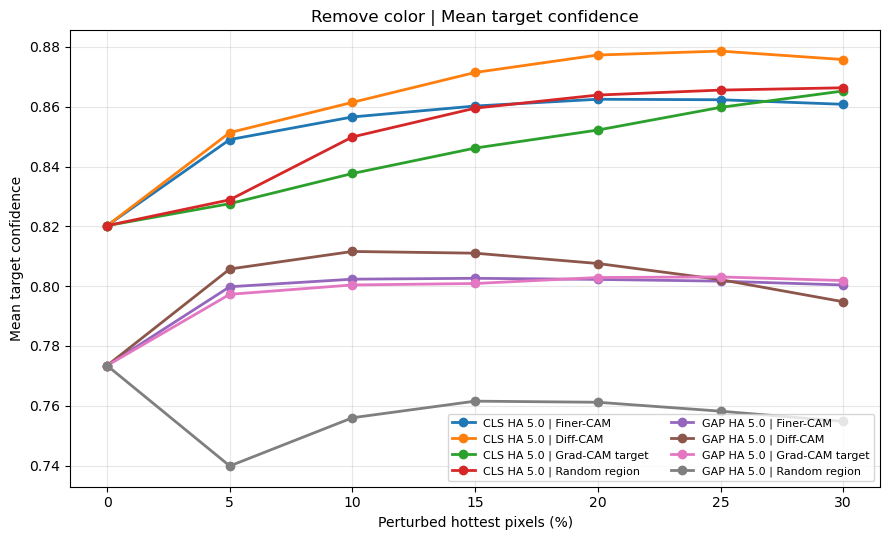

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/perturbation_confidence_all_test_block-1/curve_target_confidence_desaturate.png


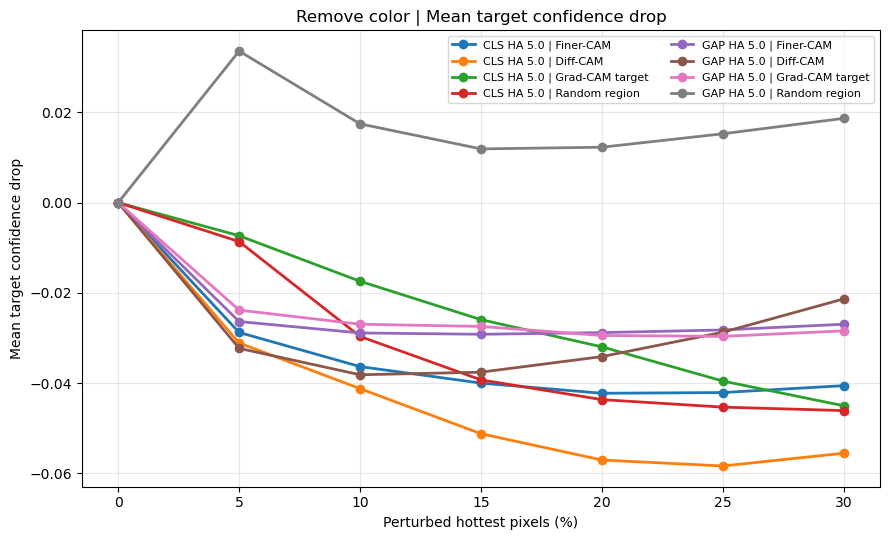

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/perturbation_confidence_all_test_block-1/curve_target_drop_desaturate.png


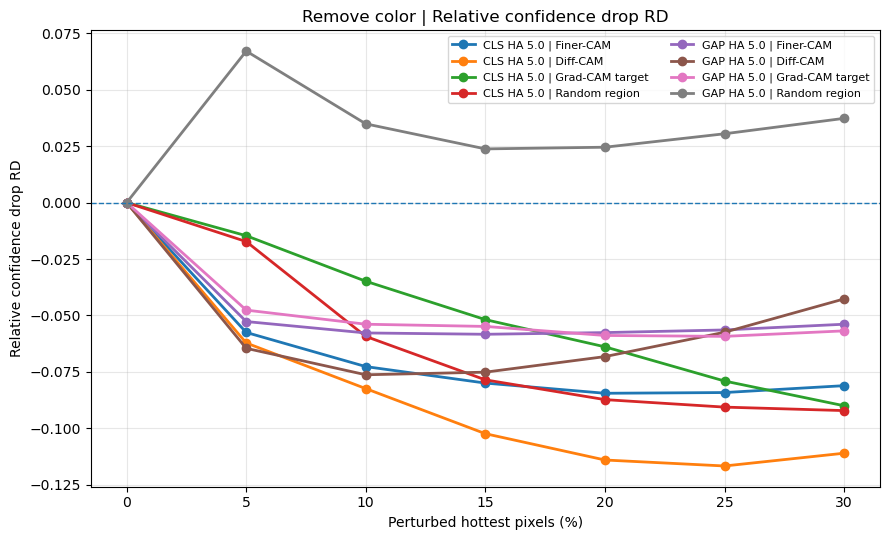

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/perturbation_confidence_all_test_block-1/curve_rd_desaturate.png


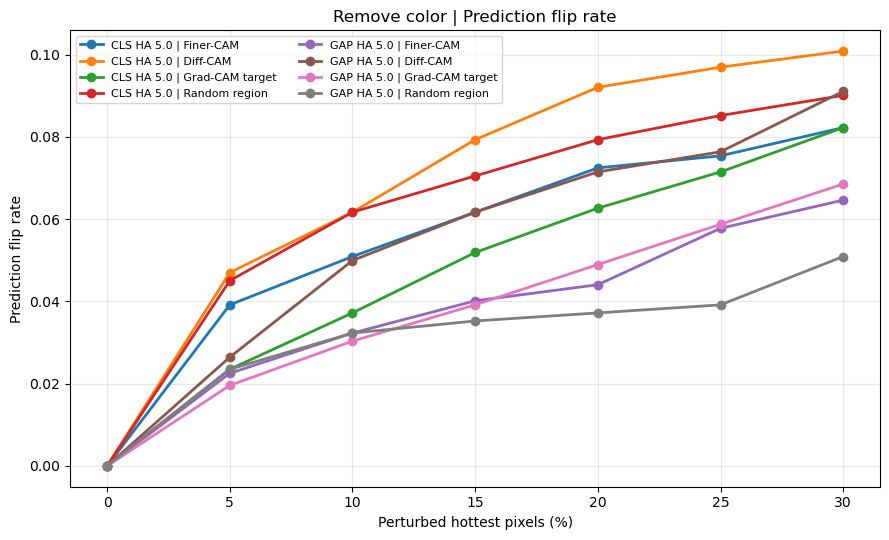

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/perturbation_confidence_all_test_block-1/curve_flip_rate_desaturate.png


In [11]:
method_display = {
    "gradcam_target": "Grad-CAM target",
    "gradcam_diff": "Diff-CAM",
    "finercam": "Finer-CAM",
    "random_region": "Random region",
}

perturb_display = {
    "darken": "Darken region",
    "desaturate": "Remove color",
    "gaussian_noise": "Add visual noise",
}


def plot_metric_curves(summary_df, perturbation_type: str, metric_col: str, ylabel: str, filename_prefix: str):
    sub = summary_df[summary_df["perturbation_type"] == perturbation_type].copy()
    if len(sub) == 0:
        print("No data for", perturbation_type)
        return

    plt.figure(figsize=(9, 5.5))
    for (model_short_name, method), m in sub.groupby(["model_short_name", "method"]):
        m = m.sort_values("ratio")
        label_model = m["model_name"].iloc[0]
        label = f"{label_model} | {method_display.get(method, method)}"
        plt.plot(m["ratio"].values * 100, m[metric_col].values, marker="o", linewidth=2, label=label)

    if metric_col == "finer_cam_rd_mean":
        plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Perturbed hottest pixels (%)")
    plt.ylabel(ylabel)
    plt.title(f"{perturb_display.get(perturbation_type, perturbation_type)} | {ylabel}")
    plt.legend(fontsize=8, ncols=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = OUT_ROOT / f"{filename_prefix}_{perturbation_type}.png"
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


for ptype in PERTURBATION_TYPES:
    plot_metric_curves(curve_summary, ptype, "target_confidence_mean", "Mean target confidence", "curve_target_confidence")
    plot_metric_curves(curve_summary, ptype, "target_drop_mean", "Mean target confidence drop", "curve_target_drop")
    plot_metric_curves(curve_summary, ptype, "finer_cam_rd_mean", "Relative confidence drop RD", "curve_rd")
    plot_metric_curves(curve_summary, ptype, "pred_changed_rate", "Prediction flip rate", "curve_flip_rate")


## 7. Visual explanation: growing perturbed region


[warn] load_state_dict mismatch: missing=2, unexpected=2
  missing sample: ['norm.weight', 'norm.bias']
  unexpected sample: ['fc_norm.weight', 'fc_norm.bias']

Loaded CLS HA 5.0
Model info: {'arch': 'PanDerm Base FT', 'variant': 'base', 'num_classes': 2, 'pooling': 'cls', 'use_mean_pooling': False, 'checkpoint_name': 'checkpoint-best-cls-ha5.pth', 'checkpoint_format': 'official_pth', 'checkpoint_model_type': 'panderm', 'use_seg_gate': False, 'seg_gate_bg_keep': 0.15, 'seg_gate_detach': True, 'class_to_idx': {'MEL': 0, 'NV': 1}, 'idx_to_class': {0: 'MEL', 1: 'NV'}, 'image_size': 224, 'stage_name': None, 'epoch': 'best'}
Target block index: -1


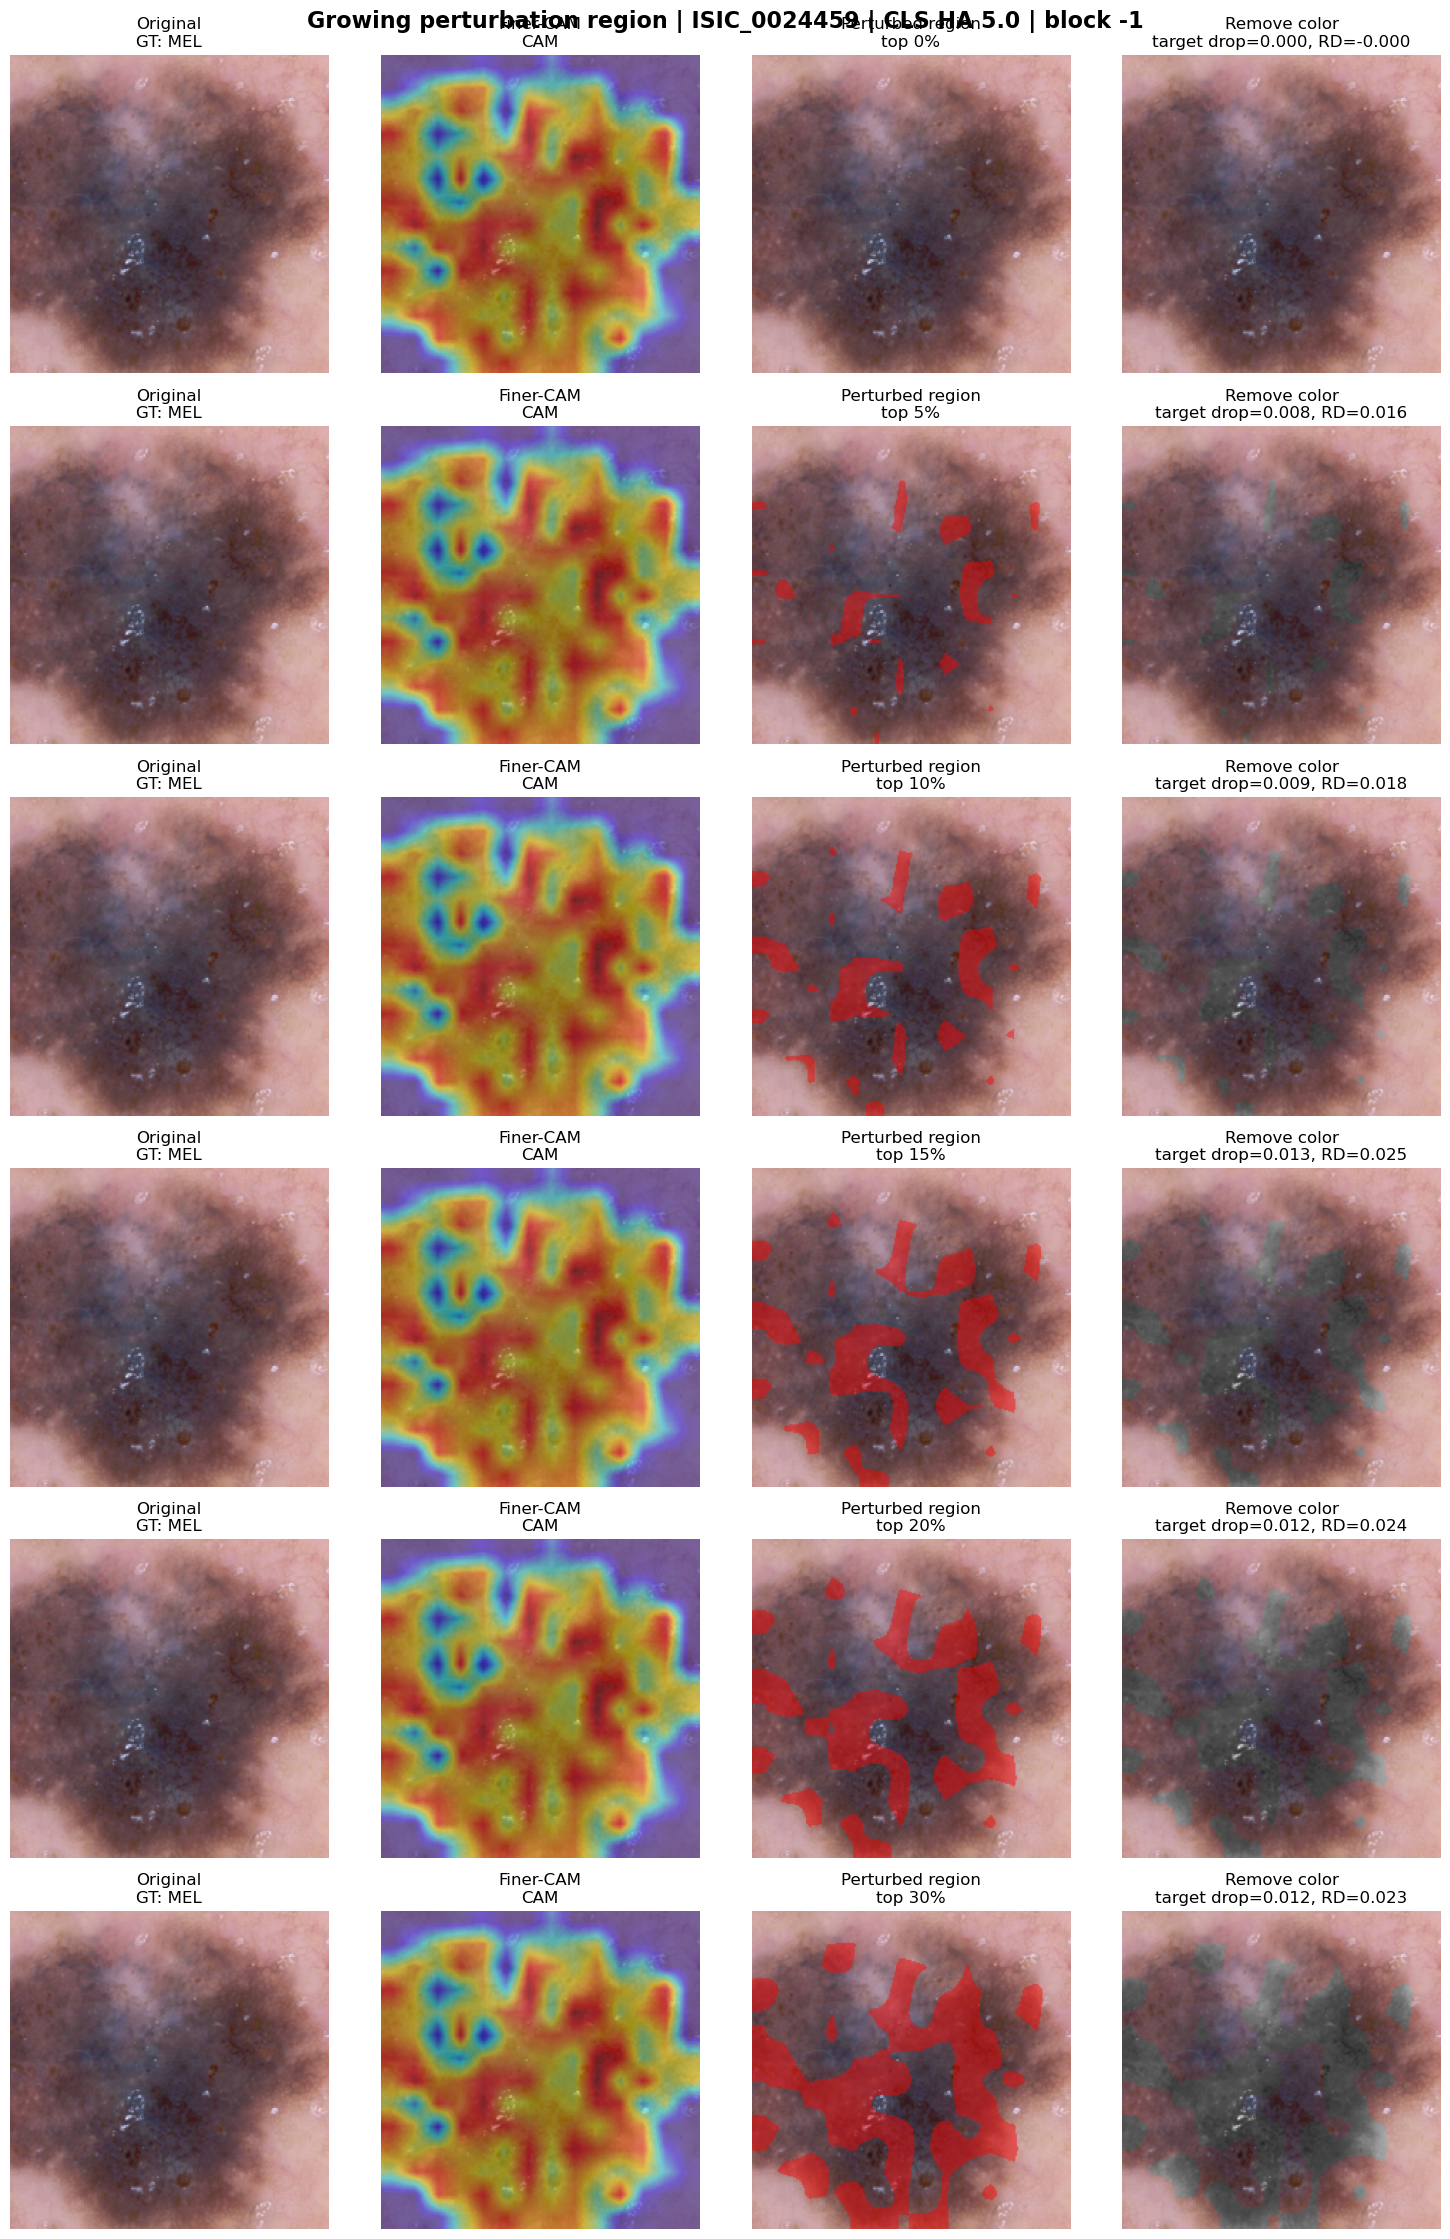

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/perturbation_confidence_all_test_block-1/visualizations/growing_region_cls_ha5_ISIC_0024459_finercam_desaturate.png


In [12]:
def get_visualization_row(image_id: str | None = None):
    if image_id is None:
        return df.iloc[0]
    matches = df[df[ID_COL].astype(str) == str(image_id)]
    if len(matches) == 0:
        raise ValueError(f"image_id not found in selected df: {image_id}")
    return matches.iloc[0]


def prepare_image_cam_and_model_for_visualization(scenario, method: str, image_id: str | None = None):
    model_raw, model, target_layer, model_info = load_scenario_model(scenario)
    cache_dir = OUT_ROOT / scenario["short_name"] / "cam_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)

    row = get_visualization_row(image_id)
    gt_idx = int(row[LABEL_COL])
    image_id = str(row[ID_COL])
    image_path = resolve_image_path(row, IMG_DIR, image_col=IMAGE_COL)
    rgb = load_rgb(image_path)
    image_tensor = transform(rgb).unsqueeze(0).to(device)

    rgb_float = np.array(rgb).astype(np.float32) / 255.0
    rgb_float = cv2.resize(rgb_float, (224, 224), interpolation=cv2.INTER_LINEAR)

    cams = compute_or_load_cams(cache_dir, model, target_layer, image_id, image_tensor, rgb_float, gt_idx)

    if method == "random_region":
        cam_np = np.zeros((224, 224), dtype=np.float32)
        cam_t = torch.zeros((1, 224, 224), dtype=torch.float32, device=device)
    else:
        if method not in cams:
            raise ValueError(f"CAM method {method} missing. Available: {list(cams.keys())}")
        cam_np = minmax_cam(cams[method])
        cam_t = cam_to_tensor(cam_np, device=device)
        cam_t = resize_cam_to_image(cam_t, image_tensor.shape[-2:])

    with torch.no_grad():
        probs = torch.softmax(model(image_tensor), dim=1)[0].detach().cpu().numpy()
    pred_idx = int(np.argmax(probs))
    target_idx, reference_idx, _ = determine_pair_indices(gt_idx)

    return {
        "scenario": scenario,
        "model_raw": model_raw,
        "model": model,
        "row": row,
        "image_id": image_id,
        "image_tensor": image_tensor,
        "rgb01": tensor_to_rgb_np(image_tensor),
        "cam_np": cam_np,
        "cam_hw": cam_t[0],
        "gt_idx": gt_idx,
        "target_idx": target_idx,
        "reference_idx": reference_idx,
        "pred_idx": pred_idx,
        "probs": probs,
    }


def plot_growing_region_grid(
    scenario=SCENARIOS[0],
    image_id: str | None = VIS_IMAGE_ID,
    method: str = VIS_METHOD,
    perturbation_type: str = VIS_PERTURBATION,
    ratios: list[float] = VIS_RATIOS,
):
    pack = prepare_image_cam_and_model_for_visualization(scenario, method, image_id=image_id)
    model = pack["model"]
    image_tensor = pack["image_tensor"]
    rgb01 = pack["rgb01"]
    cam_np = pack["cam_np"]
    cam_hw = pack["cam_hw"]
    row = pack["row"]
    target_idx = pack["target_idx"]
    reference_idx = pack["reference_idx"]
    original_probs = pack["probs"]

    rng_vis = torch.Generator(device=device)
    rng_vis.manual_seed(RANDOM_SEED)
    if method == "random_region":
        random_perm = torch.randperm(cam_hw.numel(), device=cam_hw.device, generator=rng_vis)
    else:
        random_perm = None

    fig, axes = plt.subplots(
        len(ratios),
        4,
        figsize=(15, 3.8 * len(ratios)),
    )
    if len(ratios) == 1:
        axes = np.expand_dims(axes, axis=0)

    for r_idx, ratio in enumerate(ratios):
        if method == "random_region":
            mask = random_mask_from_fixed_order(cam_hw, ratio, random_perm)
            cam_view = mask.detach().cpu().numpy().astype(np.float32)
        else:
            mask = mask_from_cam(cam_hw, ratio)
            cam_view = cam_np

        perturbed = perturb_image_soft(
            image_norm=image_tensor,
            mask_hw=mask,
            perturbation_type=perturbation_type,
            darken_factor=DARKEN_FACTOR,
            noise_std=NOISE_STD,
            generator=rng_vis,
        )
        pert_rgb = tensor_to_rgb_np(perturbed)

        with torch.no_grad():
            pert_probs = torch.softmax(model(perturbed), dim=1)[0].detach().cpu().numpy()

        target_drop = float(original_probs[target_idx] - pert_probs[target_idx])
        reference_drop = float(original_probs[reference_idx] - pert_probs[reference_idx])
        rd = target_drop - reference_drop

        mask_np = mask.detach().cpu().numpy().astype(bool)

        axes[r_idx, 0].imshow(rgb01)
        axes[r_idx, 0].set_title(f"Original\nGT: {row[GT_COL]}")
        axes[r_idx, 0].axis("off")

        axes[r_idx, 1].imshow(overlay_cam_on_rgb(rgb01, cam_view))
        axes[r_idx, 1].set_title(f"{method_display.get(method, method)}\nCAM")
        axes[r_idx, 1].axis("off")

        axes[r_idx, 2].imshow(overlay_mask_on_rgb(rgb01, mask_np))
        axes[r_idx, 2].set_title(f"Perturbed region\ntop {int(ratio * 100)}%")
        axes[r_idx, 2].axis("off")

        axes[r_idx, 3].imshow(pert_rgb)
        axes[r_idx, 3].set_title(
            f"{perturb_display.get(perturbation_type, perturbation_type)}\n"
            f"target drop={target_drop:.3f}, RD={rd:.3f}"
        )
        axes[r_idx, 3].axis("off")

    fig.suptitle(
        f"Growing perturbation region | {pack['image_id']} | {scenario['name']} | block {TARGET_BLOCK_INDEX}",
        fontsize=16,
        fontweight="bold",
    )
    plt.tight_layout()

    vis_dir = OUT_ROOT / "visualizations"
    vis_dir.mkdir(parents=True, exist_ok=True)
    out_path = vis_dir / f"growing_region_{scenario['short_name']}_{pack['image_id']}_{method}_{perturbation_type}.png"
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

    del pack["model_raw"], pack["model"]
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


plot_growing_region_grid(
    scenario=SCENARIOS[0],
    image_id=VIS_IMAGE_ID,
    method=VIS_METHOD,
    perturbation_type=VIS_PERTURBATION,
    ratios=VIS_RATIOS,
)


## 8. By-class summary


In [13]:
by_class = (
    ok_df
    .groupby(["model_short_name", "model_name", "gt_name", "method", "perturbation_type", "ratio"], dropna=False)
    .agg(
        n=("image_id", "count"),
        target_drop_mean=("target_drop", "mean"),
        reference_drop_mean=("reference_drop", "mean"),
        finer_cam_rd_mean=("finer_cam_rd", "mean"),
        pred_changed_rate=("pred_changed", "mean"),
    )
    .reset_index()
)

by_class_path = OUT_ROOT / "incremental_soft_perturbation_summary_by_class.csv"
by_class.to_csv(by_class_path, index=False)
print("Saved:", by_class_path)
display(by_class.head(20))


Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/perturbation_confidence_all_test_block-1/incremental_soft_perturbation_summary_by_class.csv


,model_short_name,model_name,gt_name,method,perturbation_type,ratio,n,target_drop_mean,reference_drop_mean,finer_cam_rd_mean,pred_changed_rate
0,cls_ha5,CLS HA 5.0,MEL,finercam,darken,0.00,70,-5.534717e-09,7.685074e-09,-1.321979e-08,0.000000
1,cls_ha5,CLS HA 5.0,MEL,finercam,darken,0.05,70,8.526993e-02,-8.526994e-02,1.705399e-01,0.071429
2,cls_ha5,CLS HA 5.0,MEL,finercam,darken,0.10,70,1.074153e-01,-1.074153e-01,2.148306e-01,0.071429
3,cls_ha5,CLS HA 5.0,MEL,finercam,darken,0.15,70,1.259614e-01,-1.259614e-01,2.519229e-01,0.100000
4,cls_ha5,CLS HA 5.0,MEL,finercam,darken,0.20,70,1.498496e-01,-1.498496e-01,2.996992e-01,0.071429
5,cls_ha5,CLS HA 5.0,MEL,finercam,darken,0.25,70,1.661877e-01,-1.661877e-01,3.323755e-01,0.100000
6,cls_ha5,CLS HA 5.0,MEL,finercam,darken,0.30,70,1.755997e-01,-1.755997e-01,3.511993e-01,0.100000
7,cls_ha5,CLS HA 5.0,MEL,finercam,desaturate,0.00,70,-5.534717e-09,7.685074e-09,-1.321979e-08,0.000000
8,cls_ha5,CLS HA 5.0,MEL,finercam,desaturate,0.05,70,3.284594e-02,-3.284594e-02,6.569188e-02,0.057143
9,cls_ha5,CLS HA 5.0,MEL,finercam,desaturate,0.10,70,4.833072e-02,-4.833072e-02,9.666144e-02,0.071429


## 9. Interpretation guide

- **Target confidence curve down:** perturbing the highlighted region reduces evidence for the target class.
- **Target drop curve up:** the highlighted region increasingly affects model confidence.
- **RD curve up:** the perturbed region is more specific to the target class than the reference class.
- **Random baseline:** checks whether CAM regions matter more than random regions of equal size.
- **Desaturate:** especially useful in dermatology because color is clinically important.
- **Darken:** close to deletion, but visually softer than setting pixels to black.
- **Gaussian noise:** disrupts local texture and pattern information.

Good thesis wording:

> Incrementally perturbing the CAM-selected regions caused a systematic reduction in target-class confidence. This suggests that the highlighted regions are functionally relevant for the model prediction. However, this perturbation test does not prove that the regions are clinically meaningful, which is why dermatologist evaluation remains necessary.
